# 03 - Entraînement des modèles avec tracking MLflow

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, confusion_matrix, recall_score
import warnings

warnings.filterwarnings('ignore')

print('MLflow version :', mlflow.__version__)

MLflow version : 3.10.1


## 1. Chargement des données

In [2]:
df = pd.read_csv('../data/processed/dataset_final.csv')

X = df.drop(columns=['TARGET'])
y = df['TARGET']

# Stratified pour conserver le ratio 8%/92% dans les deux splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape} — défauts : {y_train.mean()*100:.2f}%')
print(f'Test  : {X_test.shape}  — défauts : {y_test.mean()*100:.2f}%')

Train : (246008, 120) — défauts : 8.07%
Test  : (61503, 120)  — défauts : 8.07%


## 2. Configuration MLflow

MLflow organise les runs en **expériences**. On crée une expérience dédiée à ce projet, puis chaque entraînement sera un **run** traçable dans l'UI.

In [3]:
# Dossier où MLflow stocke les runs (relatif au notebook)
mlflow.set_tracking_uri('../mlruns')

# Création (ou récupération) de l'expérience
mlflow.set_experiment('scoring-credit')

print('Tracking URI :', mlflow.get_tracking_uri())
print('Expérience :', mlflow.get_experiment_by_name('scoring-credit').name)

2026/03/30 12:56:15 INFO mlflow.tracking.fluent: Experiment with name 'scoring-credit' does not exist. Creating a new experiment.


Tracking URI : ../mlruns
Expérience : scoring-credit


**Analyse :** L'expérience `scoring-credit` est créée. MLflow a généré le dossier `mlruns/` à la racine du projet — c'est là que tous les runs seront stockés.

## 3. Entraînement 
### 3.1 Logistic Regression (baseline)

On commence par le modèle le plus simple. `class_weight='balanced'` compense le déséquilibre des classes (8% de défauts). On évalue avec `StratifiedKFold` pour que chaque fold respecte la proportion des classes.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

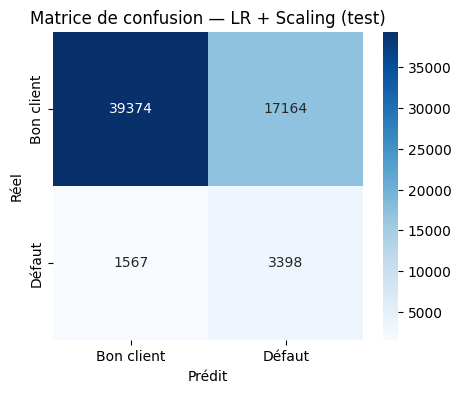

                CV      Test
AUC         0.7539    0.7582
Sensibil.   0.6822    0.6844
Specific.   0.6947    0.6964


In [5]:
model_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

with mlflow.start_run(run_name='logistic_regression'):

    y_prob_train = cross_val_predict(model_lr, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    y_pred_train = (y_prob_train >= 0.5).astype(int)

    model_lr.fit(X_train, y_train)
    y_prob_test = model_lr.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    auc_cv   = roc_auc_score(y_train, y_prob_train)
    auc_test = roc_auc_score(y_test, y_prob_test)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_train).ravel()
    sensibilite_cv  = tp / (tp + fn)
    specificite_cv  = tn / (tn + fp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
    sensibilite_test = tp / (tp + fn)
    specificite_test = tn / (tn + fp)

    mlflow.log_param('model', 'LogisticRegression')
    mlflow.log_param('scaling', 'StandardScaler')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metric('auc_cv',           auc_cv)
    mlflow.log_metric('auc_test',         auc_test)
    mlflow.log_metric('sensibilite_cv',   sensibilite_cv)
    mlflow.log_metric('sensibilite_test', sensibilite_test)
    mlflow.log_metric('specificite_cv',   specificite_cv)
    mlflow.log_metric('specificite_test', specificite_test)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bon client', 'Défaut'],
                yticklabels=['Bon client', 'Défaut'])
    ax.set_xlabel('Prédit') ; ax.set_ylabel('Réel')
    ax.set_title('Matrice de confusion — LR + Scaling (test)')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()

    print(f'          {"CV":>8}  {"Test":>8}')
    print(f'AUC       {auc_cv:>8.4f}  {auc_test:>8.4f}')
    print(f'Sensibil. {sensibilite_cv:>8.4f}  {sensibilite_test:>8.4f}')
    print(f'Specific. {specificite_cv:>8.4f}  {specificite_test:>8.4f}')

**Analyse — Logistic Regression :** AUC test = 0.758, sensibilité = 0.684, spécificité = 0.696. Résultats stables (CV ≈ Test → pas d'overfitting). Le modèle classe correctement 68% des vrais défauts — pas mal pour un modèle linéaire. Ce sera notre **baseline** pour comparer les modèles suivants.

### 3.2 Random Forest

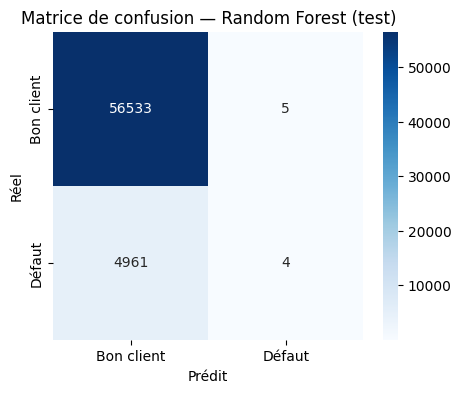

                CV      Test
AUC         0.7388    0.7455
Sensibil.   0.0012    0.0008
Specific.   0.9999    0.9999


In [6]:
model_rf = RandomForestClassifier(
    n_estimators=100,       # nombre d'arbres
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # utilise tous les cœurs disponibles
)

with mlflow.start_run(run_name='random_forest'):

    y_prob_train = cross_val_predict(model_rf, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    y_pred_train = (y_prob_train >= 0.5).astype(int)

    model_rf.fit(X_train, y_train)
    y_prob_test = model_rf.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    auc_cv   = roc_auc_score(y_train, y_prob_train)
    auc_test = roc_auc_score(y_test, y_prob_test)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_train).ravel()
    sensibilite_cv  = tp / (tp + fn)
    specificite_cv  = tn / (tn + fp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
    sensibilite_test = tp / (tp + fn)
    specificite_test = tn / (tn + fp)

    mlflow.log_param('model', 'RandomForest')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metric('auc_cv',           auc_cv)
    mlflow.log_metric('auc_test',         auc_test)
    mlflow.log_metric('sensibilite_cv',   sensibilite_cv)
    mlflow.log_metric('sensibilite_test', sensibilite_test)
    mlflow.log_metric('specificite_cv',   specificite_cv)
    mlflow.log_metric('specificite_test', specificite_test)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bon client', 'Défaut'],
                yticklabels=['Bon client', 'Défaut'])
    ax.set_xlabel('Prédit') ; ax.set_ylabel('Réel')
    ax.set_title('Matrice de confusion — Random Forest (test)')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()

    print(f'          {"CV":>8}  {"Test":>8}')
    print(f'AUC       {auc_cv:>8.4f}  {auc_test:>8.4f}')
    print(f'Sensibil. {sensibilite_cv:>8.4f}  {sensibilite_test:>8.4f}')
    print(f'Specific. {specificite_cv:>8.4f}  {specificite_test:>8.4f}')

**Analyse — Random Forest :** AUC test = 0.745 mais sensibilité quasi nulle (0.001). L'AUC prouve que le modèle **sait discriminer** les deux classes (il le fait sur les différents seuils calculés par la courbe ROC), mais avec le seuil par défaut de 0.5 il prédit presque tout "bon client". Cause : même avec `class_weight='balanced'`, les arbres de décision tendent à sur-représenter la classe majoritaire au niveau des feuilles. On continue avec XGBoost.

### 3.3 XGBoost

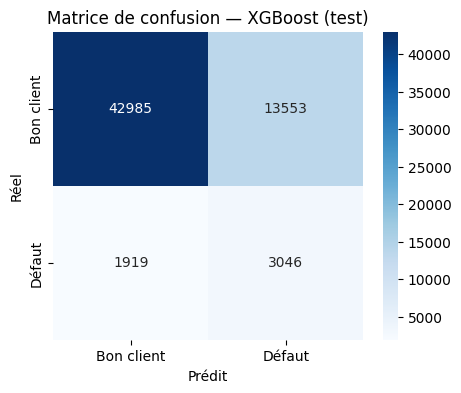

                CV      Test
AUC         0.7520    0.7575
Sensibil.   0.5930    0.6135
Specific.   0.7700    0.7603


In [7]:
# scale_pos_weight compense le déséquilibre : ratio bons clients / défauts
scale = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,  # équivalent de class_weight='balanced' pour XGBoost
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)

with mlflow.start_run(run_name='xgboost'):

    y_prob_train = cross_val_predict(model_xgb, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    y_pred_train = (y_prob_train >= 0.5).astype(int)

    model_xgb.fit(X_train, y_train)
    y_prob_test = model_xgb.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    auc_cv   = roc_auc_score(y_train, y_prob_train)
    auc_test = roc_auc_score(y_test, y_prob_test)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_train).ravel()
    sensibilite_cv  = tp / (tp + fn)
    specificite_cv  = tn / (tn + fp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
    sensibilite_test = tp / (tp + fn)
    specificite_test = tn / (tn + fp)

    mlflow.log_param('model', 'XGBoost')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('scale_pos_weight', round(scale, 2))
    mlflow.log_metric('auc_cv',           auc_cv)
    mlflow.log_metric('auc_test',         auc_test)
    mlflow.log_metric('sensibilite_cv',   sensibilite_cv)
    mlflow.log_metric('sensibilite_test', sensibilite_test)
    mlflow.log_metric('specificite_cv',   specificite_cv)
    mlflow.log_metric('specificite_test', specificite_test)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bon client', 'Défaut'],
                yticklabels=['Bon client', 'Défaut'])
    ax.set_xlabel('Prédit') ; ax.set_ylabel('Réel')
    ax.set_title('Matrice de confusion — XGBoost (test)')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()

    print(f'          {"CV":>8}  {"Test":>8}')
    print(f'AUC       {auc_cv:>8.4f}  {auc_test:>8.4f}')
    print(f'Sensibil. {sensibilite_cv:>8.4f}  {sensibilite_test:>8.4f}')
    print(f'Specific. {specificite_cv:>8.4f}  {specificite_test:>8.4f}')

**Analyse — XGBoost :** AUC test = 0.758, sensibilité = 0.614, spécificité = 0.760. Le `scale_pos_weight` a bien rééquilibré les prédictions — sensibilité correcte contrairement au Random Forest. AUC identique à la LR mais meilleure spécificité (+0.06). CV ≈ Test → pas d'overfitting. On passe à LightGBM.

### 3.4 LightGBM

LightGBM est souvent plus rapide et plus performant que XGBoost sur les grands datasets. Il gère nativement les valeurs manquantes et les variables catégorielles.

In [8]:
import re

# ERREUR : [LightGBM] [Fatal] Do not support special JSON characters in feature name.
# Remplacement de tous les caractères spéciaux par des underscores
X_train.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X_train.columns]
X_test.columns  = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in X_test.columns]

print('Colonnes nettoyées')

Colonnes nettoyées


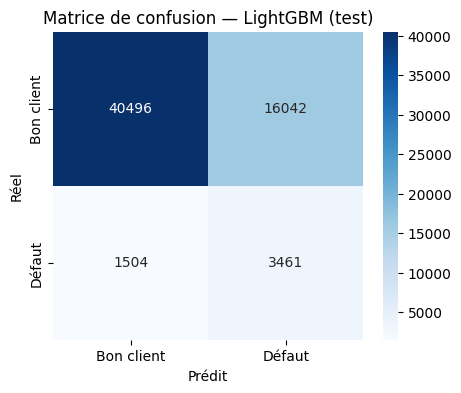

                CV      Test
AUC         0.7667    0.7719
Sensibil.   0.6783    0.6971
Specific.   0.7174    0.7163


In [9]:
model_lgbm = LGBMClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1       # supprime les logs d'entraînement
)

with mlflow.start_run(run_name='lightgbm'):

    y_prob_train = cross_val_predict(model_lgbm, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    y_pred_train = (y_prob_train >= 0.5).astype(int)

    model_lgbm.fit(X_train, y_train)
    y_prob_test = model_lgbm.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    auc_cv   = roc_auc_score(y_train, y_prob_train)
    auc_test = roc_auc_score(y_test, y_prob_test)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_train).ravel()
    sensibilite_cv  = tp / (tp + fn)
    specificite_cv  = tn / (tn + fp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
    sensibilite_test = tp / (tp + fn)
    specificite_test = tn / (tn + fp)

    mlflow.log_param('model', 'LightGBM')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metric('auc_cv',           auc_cv)
    mlflow.log_metric('auc_test',         auc_test)
    mlflow.log_metric('sensibilite_cv',   sensibilite_cv)
    mlflow.log_metric('sensibilite_test', sensibilite_test)
    mlflow.log_metric('specificite_cv',   specificite_cv)
    mlflow.log_metric('specificite_test', specificite_test)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bon client', 'Défaut'],
                yticklabels=['Bon client', 'Défaut'])
    ax.set_xlabel('Prédit') ; ax.set_ylabel('Réel')
    ax.set_title('Matrice de confusion — LightGBM (test)')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()

    print(f'          {"CV":>8}  {"Test":>8}')
    print(f'AUC       {auc_cv:>8.4f}  {auc_test:>8.4f}')
    print(f'Sensibil. {sensibilite_cv:>8.4f}  {sensibilite_test:>8.4f}')
    print(f'Specific. {specificite_cv:>8.4f}  {specificite_test:>8.4f}')

**Analyse — LightGBM :** AUC test = 0.772, sensibilité = 0.697, spécificité = 0.716. Meilleur sur toutes les métriques : +0.014 AUC vs LR et XGBoost, meilleure sensibilité (+0.01 vs LR). CV ≈ Test → stable. LightGBM est retenu comme modèle candidat pour l'optimisation.

### 3.5 MLP (Réseau de neurones)

Le MLP (Multi-Layer Perceptron) est un réseau de neurones simple. Contrairement aux arbres, il est sensible à l'échelle des données — il faut **normaliser les features** avant de l'entraîner.

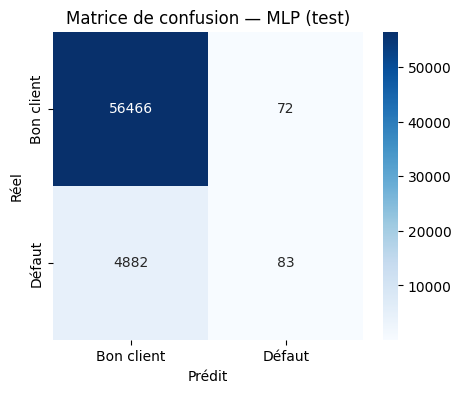

                CV      Test
AUC         0.7496    0.7564
Sensibil.   0.0107    0.0167
Specific.   0.9990    0.9987


In [10]:
# Pipeline : normalisation + MLP (obligatoire pour les réseaux de neurones)
model_mlp = Pipeline([
    ('scaler', StandardScaler()),       # centre et réduit chaque feature (moyenne=0, std=1)
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32),    # 2 couches cachées : 64 puis 32 neurones
        max_iter=100,
        random_state=42,
        early_stopping=True,            # arrêt si la validation ne s'améliore plus
        validation_fraction=0.1
    ))
])

with mlflow.start_run(run_name='mlp'):

    y_prob_train = cross_val_predict(model_mlp, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    y_pred_train = (y_prob_train >= 0.5).astype(int)

    model_mlp.fit(X_train, y_train)
    y_prob_test = model_mlp.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    auc_cv   = roc_auc_score(y_train, y_prob_train)
    auc_test = roc_auc_score(y_test, y_prob_test)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_train).ravel()
    sensibilite_cv  = tp / (tp + fn)
    specificite_cv  = tn / (tn + fp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
    sensibilite_test = tp / (tp + fn)
    specificite_test = tn / (tn + fp)

    mlflow.log_param('model', 'MLP')
    mlflow.log_param('hidden_layers', '64-32')
    mlflow.log_param('early_stopping', True)
    mlflow.log_metric('auc_cv',           auc_cv)
    mlflow.log_metric('auc_test',         auc_test)
    mlflow.log_metric('sensibilite_cv',   sensibilite_cv)
    mlflow.log_metric('sensibilite_test', sensibilite_test)
    mlflow.log_metric('specificite_cv',   specificite_cv)
    mlflow.log_metric('specificite_test', specificite_test)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bon client', 'Défaut'],
                yticklabels=['Bon client', 'Défaut'])
    ax.set_xlabel('Prédit') ; ax.set_ylabel('Réel')
    ax.set_title('Matrice de confusion — MLP (test)')
    mlflow.log_figure(fig, 'confusion_matrix.png')
    plt.show()

    print(f'          {"CV":>8}  {"Test":>8}')
    print(f'AUC       {auc_cv:>8.4f}  {auc_test:>8.4f}')
    print(f'Sensibil. {sensibilite_cv:>8.4f}  {sensibilite_test:>8.4f}')
    print(f'Specific. {specificite_cv:>8.4f}  {specificite_test:>8.4f}')

**Analyse — MLP :** AUC test = 0.756, sensibilité = 0.017, spécificité = 0.999. Même problème que le Random Forest : `MLPClassifier` ne supporte pas `class_weight` — le modèle ignore presque totalement la classe minoritaire. L'AUC reste correcte car la courbe ROC balaie tous les seuils, mais en pratique ce modèle est inutilisable sans correction du déséquilibre.

## Conclusion — Comparaison des modèles

| Modèle | AUC test | Sensibilité | Spécificité |
|---|---|---|---|
| Logistic Regression | 0.758 | 0.684 | 0.696 |
| Random Forest | 0.745 | 0.001 | 0.999 |
| XGBoost | 0.758 | 0.614 | 0.760 |
| **LightGBM** | **0.772** | **0.697** | **0.716** |
| MLP | 0.756 | 0.017 | 0.999 |

**LightGBM** est le meilleur modèle sur les trois métriques. Random Forest et MLP sont écartés : sensibilité quasi nulle due au déséquilibre non corrigé. LightGBM sera optimisé dans `04_optimisation.ipynb`.